In [57]:
%config InlineBackend.figure_format = 'retina'


In [109]:
import polars as pl
from pathlib import Path
from glob import glob
import geopandas as gpd
import contextily as ctx
import seaborn as sns
import pyarrow
import pandas as pd
import matplotlib.pyplot as plt
import waxwing
waxwing.set_figsize(8,3)

In [110]:
dataset_meta = pl.read_excel(
    "../datasets/butterfly-data-paper-slim/1_raw_data/program-permissions-table.xlsx"
)
datasets_w_coords = dataset_meta.filter(pl.col("lat.lon") == "Actual")[
    "program.name"
].to_list()
datasets_w_coords

['Michigan Butterfly Network',
 'Missouri Butterfly Monitoring Network',
 'MPG Ranch Butterfly Monitoring Program',
 'Nevada Butterfly Monitoring Network',
 'New Mexico Butterfly Monitoring Network',
 'Ohio Lepidopterists',
 'PRISSM (Partnership of Regional Institutions for Sage Scrub Monitoring)',
 'Art Shapiro Data',
 'Tennessee BMN (Zoo Knoxville)']

In [111]:
dataset_to_filename = {
    s: s.lower().replace(" ", "_").replace("(", "").replace(")", "") + "-cleaned.xlsx"
    for s in datasets_w_coords
}

dataset_root = Path("../datasets/butterfly-data-paper-slim/4_res/individual share/")
dataset_paths = {
    name: dataset_root / filename for name, filename in dataset_to_filename.items()
}
[p.exists() for p in dataset_paths.values()]

[True, True, True, True, True, True, True, True, True]

In [112]:
datasets = []
for name, p in dataset_paths.items():
    df = pl.read_excel(p)
    df = df.with_columns(
        pl.col("duration").cast(pl.Float64), pl.lit(name).alias("dataset_name")
    )
    datasets.append(df)

Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 14, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 15, falling back to string
Could not determine dtype for column 16, falling back to string
Could not determine dtype for column 14,

check all have same cols

In [113]:
first_dataset_cols = set(datasets[0].columns)
[set(d.columns).difference(first_dataset_cols) for d in datasets]

[set(), set(), set(), set(), set(), set(), set(), set(), set()]

In [114]:
# duration always float
for i in range(len(datasets)):
    datasets[i] = datasets[i].with_columns(pl.col("duration").cast(pl.Float64))

In [115]:
combined = pl.concat(datasets, rechunk=True).with_columns(
    pl.col("Reported species name").str.split(" ").list.get(0).alias("genus")
)

In [116]:
combined["lat-lon precision"].value_counts()

lat-lon precision,count
str,u32
"""Actual""",695474


In [117]:
# summarize by # unique species
# also keep the lat/lon for plotting
sp_counts_and_latlon = (
    combined.group_by("site")
    .agg(
        pl.col("lat").mean().alias("latitude"),
        pl.col("lon").mean().alias("longitude"),
        pl.col("GU code").n_unique().alias("unique_species"),
    )
    .sort("unique_species", descending=True)
)

gdf = gpd.GeoDataFrame(
    sp_counts_and_latlon.to_pandas(),
    geometry=gpd.points_from_xy(
        sp_counts_and_latlon["longitude"], sp_counts_and_latlon["latitude"]
    ),
    crs="EPSG:4326",
)

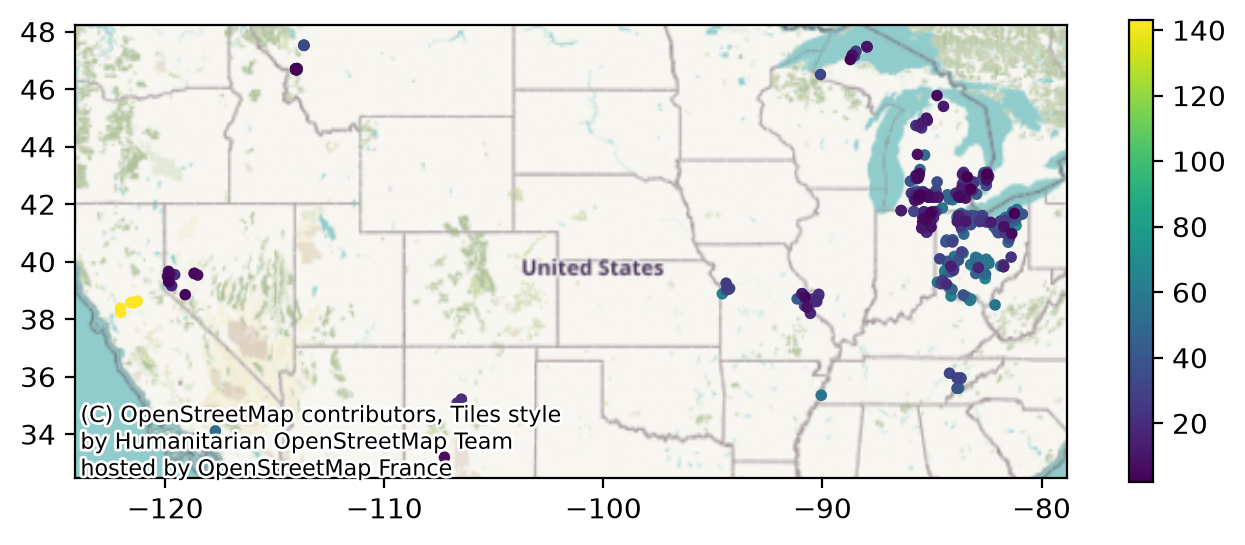

In [119]:
# plot map of sites
ax = gdf.plot(
    column="unique_species", cmap="viridis", legend=True, figsize=(8,3), s=10
)
# basemap
ctx.add_basemap(ax, crs=gdf.crs.to_string()) 

In [120]:
combined["GU code"].n_unique()

310

In [121]:
combined["genus"].n_unique()

134

> There are some very long erroneous(?) durations

In [122]:
combined.filter(pl.col("duration") > 1000)["duration"].value_counts(sort=True)

duration,count
f64,u32
1500.0,6
4449.0,5
103765.0,5
44665.0,5
1525.0,5
…,…
1497.0,4
46165.0,4
37560.0,3


<Axes: ylabel='Count'>

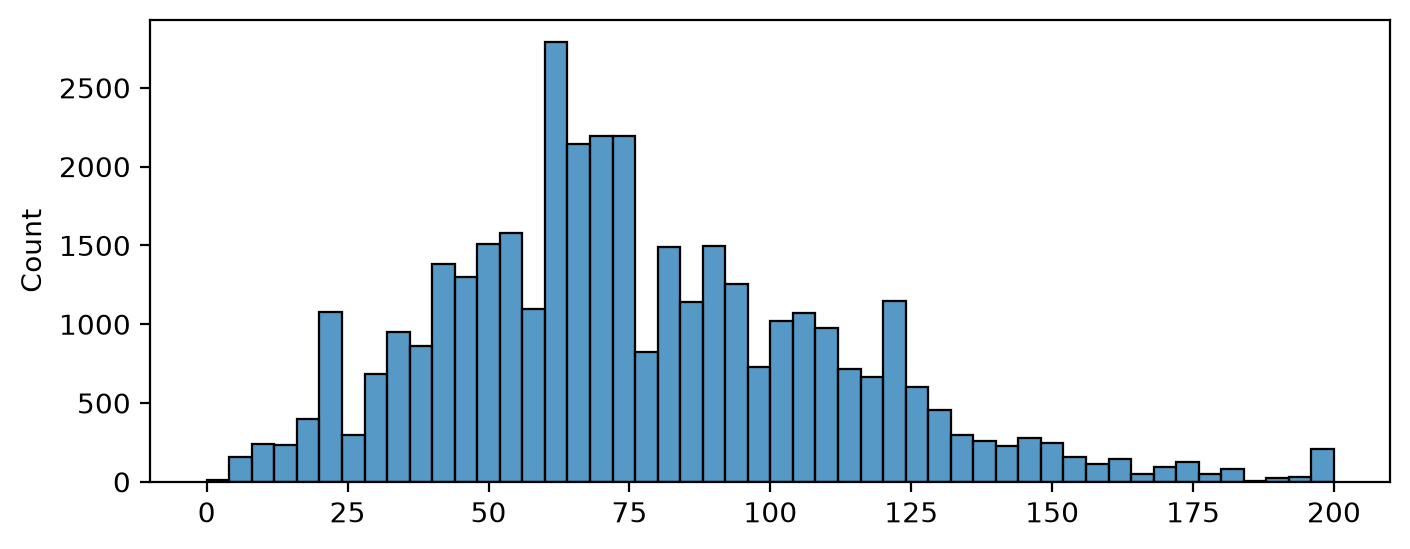

In [125]:
# note: some negative and very large outliers in duration
sns.histplot(combined["duration"].clip(0, 200), bins=50)

Text(0.5, 0, 'Number of surveys at site')

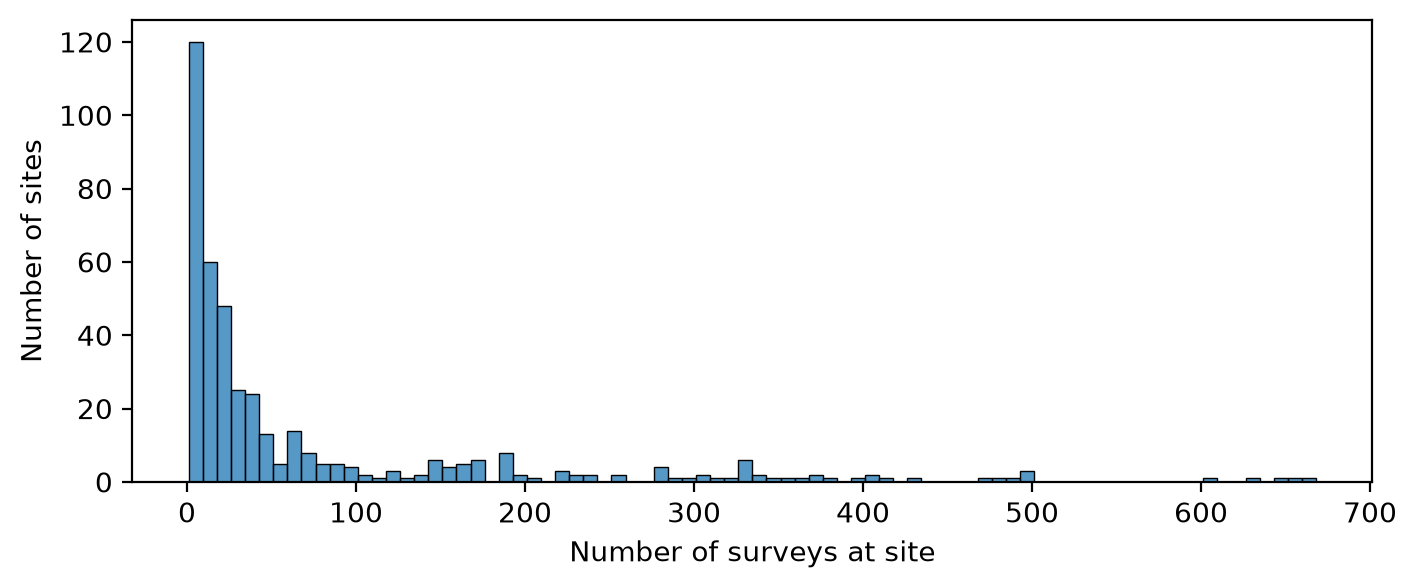

In [126]:
n_surveys_per_site = (
    combined.group_by("site")
    .agg(pl.col("event.id").n_unique().alias("Num surveys at site"))
    .sort("Num surveys at site", descending=True)
)
sns.histplot(n_surveys_per_site["Num surveys at site"], bins=80)
plt.ylabel("Number of sites")
plt.xlabel("Number of surveys at site")

In [127]:
sp_counts_and_latlon.sort("unique_species", descending=False).head(10)

site,latitude,longitude,unique_species
str,f64,f64,u32
"""GU:MI-32805""",42.942501,-83.383558,2
"""GU:MI-9820""",43.039951,-82.490021,2
"""GU:MT-4888""",46.7,-114.04,2
"""GU:NV-27220""",39.307481,-119.833386,3
"""GU:MI-12228""",42.522099,-83.231499,3
"""GU:OH-113""",41.675,-81.23817,3
"""GU:MI-3948""",42.294106,-85.603432,3
"""GU:MI-7245""",47.029446,-88.726242,3
"""GU:MI-12334""",42.308929,-85.521843,3


<Axes: xlabel='Number of unique species at site', ylabel='Number of sites'>

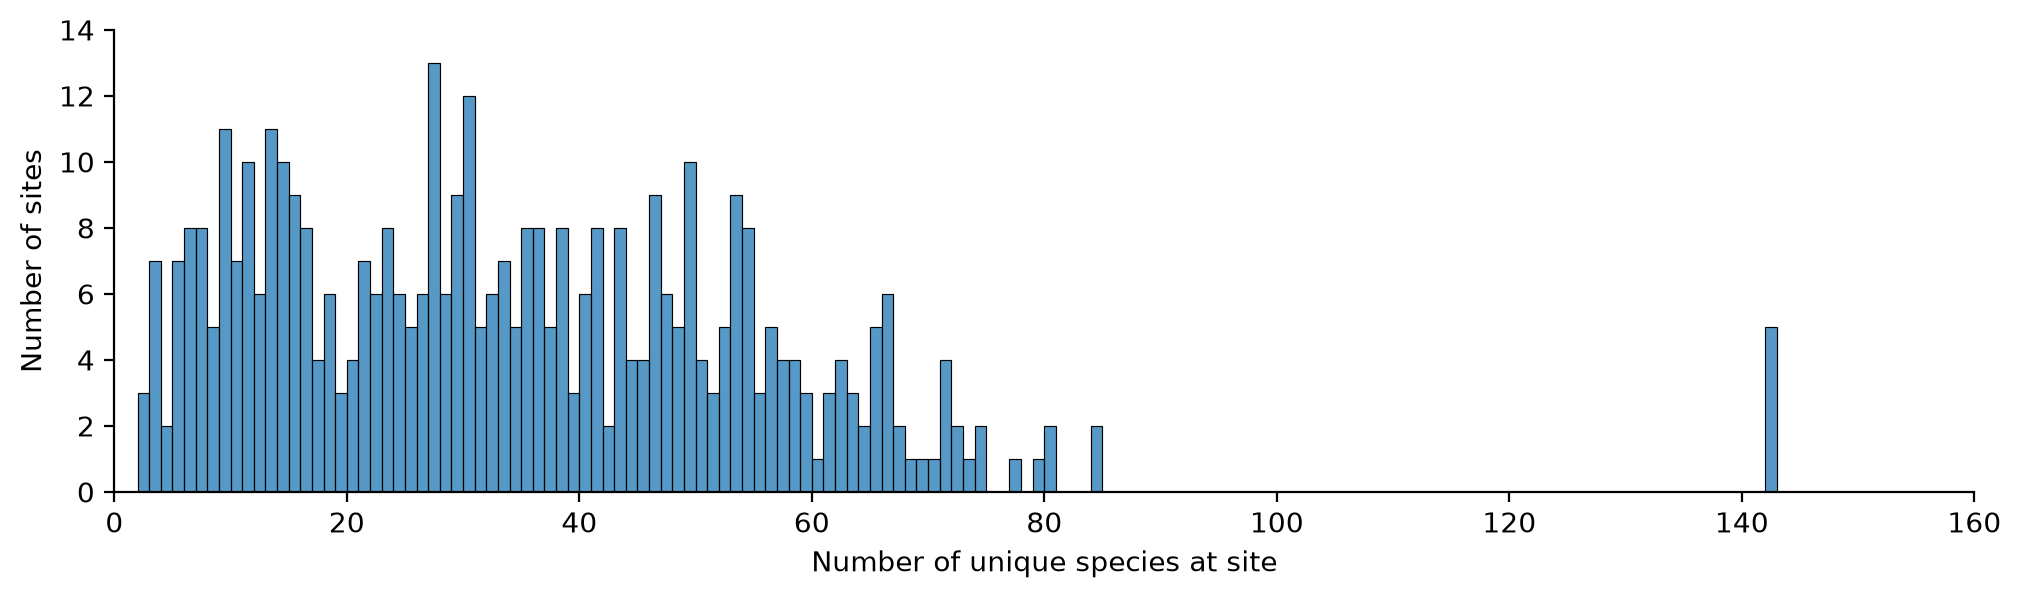

In [ ]:
import numpy as np

plt.figure(figsize=(12, 3))

sns.histplot(
    sp_counts_and_latlon["unique_species"],
    bins=np.arange(0, sp_counts_and_latlon["unique_species"].max() + 1, 1),
)
plt.ylabel("Number of sites")
plt.xlabel("Number of unique species at site")
waxwing.style_axes(pad=0)

In [129]:
# check lidar availability for each tile
import sys
sys.path.insert(0, "../src/streaming/3dep")
from get_als import lookup_3dep_by_latlon

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
# metadata table of available USGS 3DEP 

resources_aws = gpd.read_file("../src/streaming/3dep/usgs_3dep_resources_AWS.geojson")
resources_usgs = gpd.read_file("../src/streaming/3dep/usgs_3dep_resources_ALL.geojson")


In [ ]:
def lookup_3dep_by_latlon(lat, lon, earliest_year=None, latest_year=None, source="AWS"):
    """
    Lookup USGS 3DEP resources by latitude and longitude.
    
    Parameters:
    lat (float): Latitude of the point (CRS: EPSG:4326).
    lon (float): Longitude of the point (CRS: EPSG:4326).
    earliest_year (int, optional): Earliest collection year to filter resources. Defaults to None.
    latest_year (int, optional): Latest collection year to filter resources. Defaults to None.

    Returns:
    pd.DataFrame: A DataFrame containing the matching 3DEP LAS data products, which can be downloaded via PDAL
    """
    pt = Point(lon, lat)
    if source == "AWS":
        resources = resources_aws
    elif source == "USGS":
        resources = resources_usgs
    else:
        raise ValueError("Invalid source. Must be 'AWS' or 'USGS'.")
    matches = resources[resources.geometry.contains(pt)]
    if earliest_year is not None:
        matches = matches[matches['collection_year'] >= earliest_year]
    if latest_year is not None:
        matches = matches[matches['collection_year'] <= latest_year]
    return matches

import functools

@functools.lru_cache()
def get_nearest_year_product(lat, lon, year, source="AWS"):
    """
    Get the nearest 3DEP product for a given latitude, longitude, and year.
    
    Parameters:
    lat (float): Latitude of the point (CRS: EPSG:4326).
    lon (float): Longitude of the point (CRS: EPSG:4326).
    year (int): Year to find the nearest product.

    Returns:
    pd.Series: A Series containing the nearest 3DEP LAS data product information,
    or None if no products are found.
    """
    matches = lookup_3dep_by_latlon(lat, lon, source=source)
    if matches.empty:
        return None
    matches['year_diff'] = matches['collection_year'].apply(lambda x: abs(x - year))
    nearest = matches.loc[matches['year_diff'].idxmin()]

    return {
        f"product_name_{source}": nearest['name'],
        f"collection_year_{source}": int(nearest['collection_year']),
        f"year_diff_{source}": int(nearest['year_diff']),
    }

In [174]:
get_nearest_year_product(lat=37.7749, lon=-122.4194, year=2020, source="AWS")

{'product_name_AWS': 'USGS_LPC_CA_NoCAL_Wildfires_B5b_2018',
 'collection_year_AWS': 2018,
 'year_diff_AWS': 2}

Availability is lower in the AWS EPT streaming dataset than the raw USGS LAZ bucket
- spatial: 98.5 vs 99.6%
- within 3 years: 25 vs 45%

48% availability when matching to lidar within 3 years of survey on DIRECT USGS BUCKET - but many of these not available yet in EPT from AWS

In [184]:
row['lat'].item()

41.376510620117

In [185]:
row=combined[0]
get_nearest_year_product(lat=row["lat"].item(), lon=row["lon"].item(), year=row['year'].item(), source="AWS")

{'product_name_AWS': 'USGS_LPC_IN_ET_B5_Noble_2012__LAS_2016',
 'collection_year_AWS': 2016,
 'year_diff_AWS': 0}

In [192]:
result_struct_aws = pl.Struct([
    pl.Field("product_name_AWS", pl.Utf8),
    pl.Field("collection_year_AWS", pl.Int64),
    pl.Field("year_diff_AWS", pl.Int64),
])
result_struct_usgs = pl.Struct([
    pl.Field("product_name_USGS", pl.Utf8),
    pl.Field("collection_year_USGS", pl.Int64),
    pl.Field("year_diff_USGS", pl.Int64),
])

combined_with_lidar = combined.with_columns(
    pl.struct(["lat", "lon", "year"])
    .map_elements(
        lambda x: get_nearest_year_product(x["lat"], x["lon"], x["year"],source="AWS"),
        return_dtype=result_struct_aws,
    )
    .alias("nearest_3dep_aws")
).unnest("nearest_3dep_aws")



In [194]:

combined_with_lidar = combined_with_lidar.with_columns(
    pl.struct(["lat", "lon", "year"])
    .map_elements(
        lambda x: get_nearest_year_product(x["lat"], x["lon"], x["year"], source="USGS"),
        return_dtype=result_struct_usgs,
    )
    .alias("nearest_3dep_usgs")
).unnest("nearest_3dep_usgs")

/var/folders/_1/clc139q504qfy1s2zl7qf9h00000gr/T/ipykernel_66586/1481155420.py:1: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  sns.histplot(combined_with_lidar[["year_diff_AWS", "year_diff_USGS"]].melt(), x="value", hue="variable", bins=50, multiple='dodge')


<Axes: xlabel='value', ylabel='Count'>

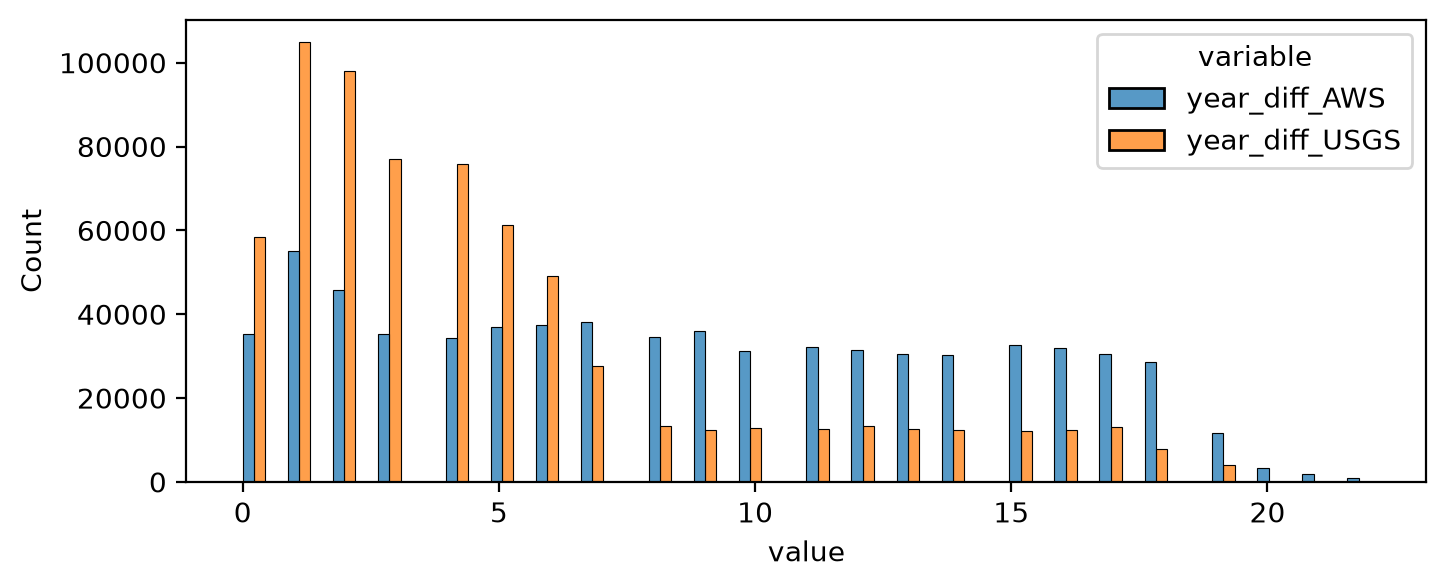

In [197]:
sns.histplot(combined_with_lidar[["year_diff_AWS", "year_diff_USGS"]].melt(), x="value", hue="variable", bins=50, multiple='dodge')

In [34]:
matched = combined.filter(combined['n_als']>0)

plots with lidar data available from within +/- 3 years of the survey date:

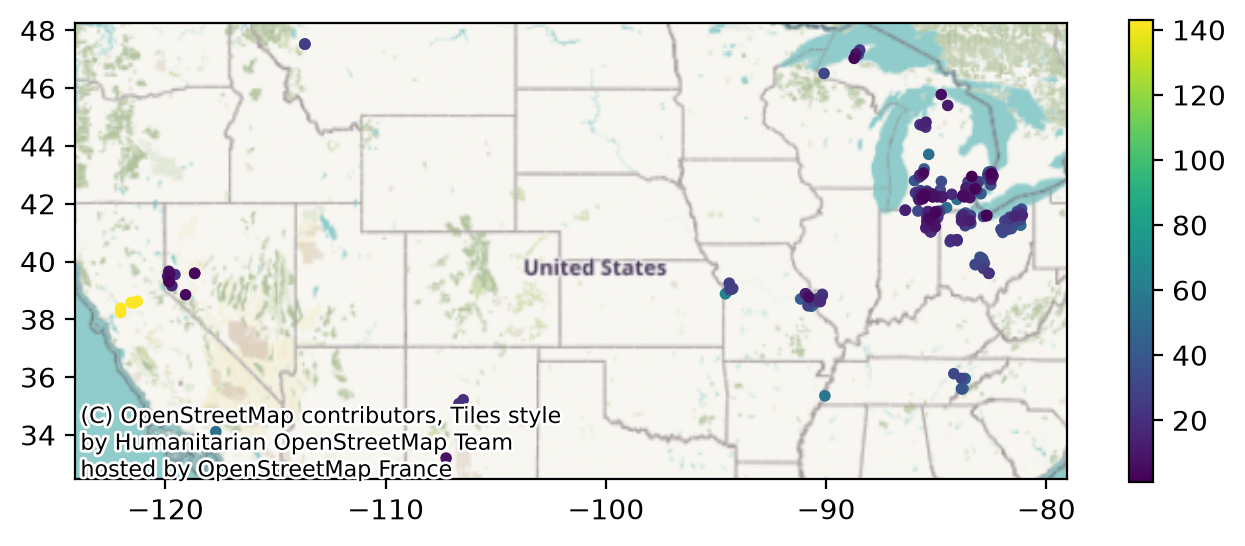

In [198]:
# plot
sp_counts_and_latlon =( matched
.group_by("site")
    .agg(
        pl.col("lat").mean().alias("latitude"),
        pl.col("lon").mean().alias("longitude"),
        pl.col("GU code").n_unique().alias("unique_species"),
    )
    .sort("unique_species", descending=True)
)

gdf = gpd.GeoDataFrame(
    sp_counts_and_latlon.to_pandas(),
    geometry=gpd.points_from_xy(
        sp_counts_and_latlon["longitude"], sp_counts_and_latlon["latitude"]
    ),
    crs="EPSG:4326",
)
gdf.plot(column='unique_species',legend=True,s=10)
ctx.add_basemap(plt.gca(), crs=gdf.crs.to_string()) 

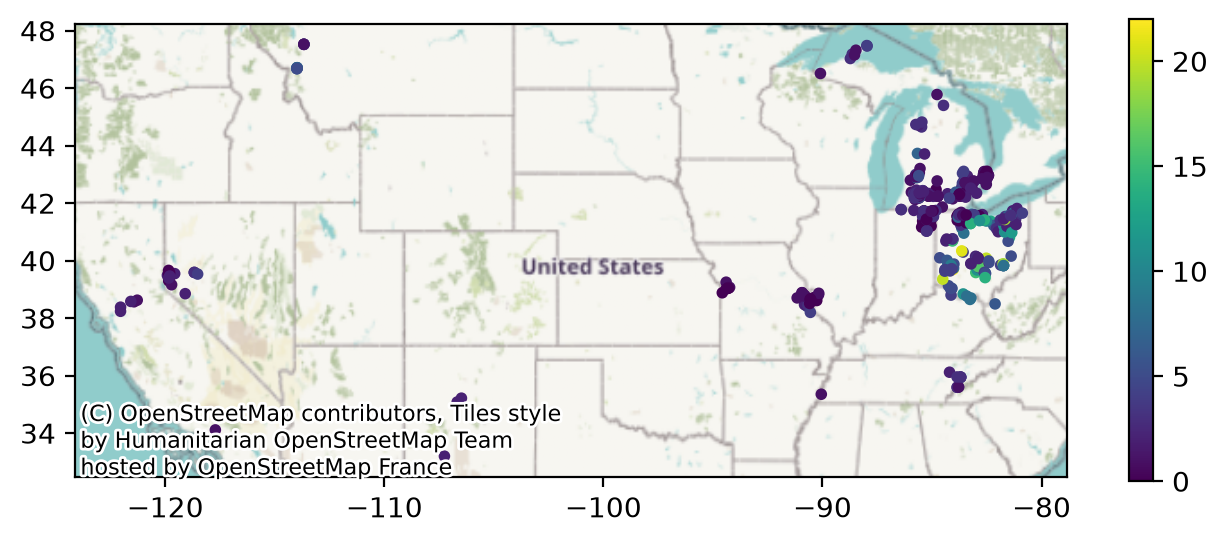

In [203]:
# map colored by year difference

# subset to last survey per site
subset = combined_with_lidar.sort("year", descending=True).group_by("site").agg(pl.first("year_diff_AWS").alias("year_diff_AWS"), pl.first("year_diff_USGS").alias("year_diff_USGS"), pl.first("lat").alias("lat"), pl.first("lon").alias("lon"))
# remove if year_diff is null
subset = subset.filter(pl.col("year_diff_AWS").is_not_null())

gdf = gpd.GeoDataFrame(
    subset.to_pandas(),
    geometry=gpd.points_from_xy(
        subset["lon"], subset["lat"]
    ),
    crs="EPSG:4326",
)
gdf.plot(column='year_diff_AWS',legend=True,s=10)
ctx.add_basemap(plt.gca(), crs=gdf.crs.to_string())

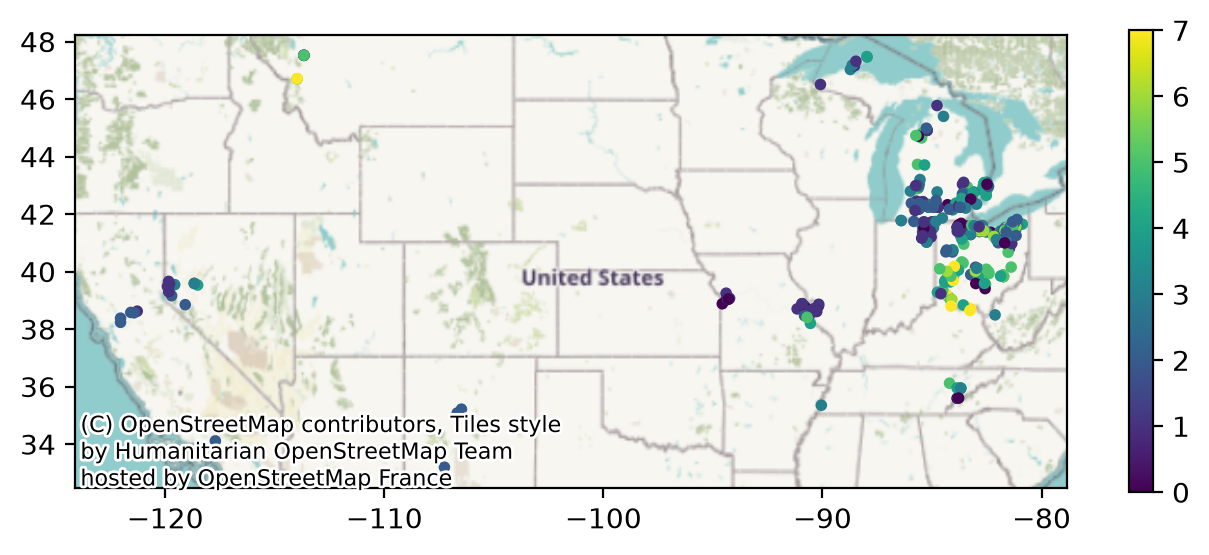

In [204]:
# map colored by year difference

# subset to last survey per site
subset = combined_with_lidar.sort("year", descending=True).group_by("site").agg(pl.first("year_diff_AWS").alias("year_diff_AWS"), pl.first("year_diff_USGS").alias("year_diff_USGS"), pl.first("lat").alias("lat"), pl.first("lon").alias("lon"))
subset = subset.filter(pl.col("year_diff_USGS").is_not_null())
gdf = gpd.GeoDataFrame(
    subset.to_pandas(),
    geometry=gpd.points_from_xy(
        subset["lon"], subset["lat"]
    ),
    crs="EPSG:4326",
)
gdf.plot(column='year_diff_USGS',legend=True,s=10)
ctx.add_basemap(plt.gca(), crs=gdf.crs.to_string())

ColumnNotFoundError: "url" not found

In [54]:
matched['event.id'].n_unique(), matched['site'].n_unique(), matched['GU code'].n_unique()

(6966, 275, 295)